In [2]:
import pickle
import numpy as np
import os 

In [3]:
# folder_graph = './data/quorum_sims_all/graphs/train_means/'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle') and file.startswith('(')] #and (file not in files_test)


# fname = 'small_graphs.pth'
valfolder = './data/quorum_sims_all/graphs/test/'
files_val= os.listdir(valfolder)
files_val = [file for file in files_val if file.endswith('.pickle') and file.startswith('(')]

In [9]:
# arr_times_train = []
arr_times_test = []
# arr_success_train = []
arr_success_test = []

for file in files_val:
    # print(valfolder+file, 'rb')
    fil = open(valfolder+file, 'rb')
    G = pickle.load(fil)
    for node in G.nodes(data=True):
        arr_times_test.append(node[1]['times_conved'])
        arr_success_test.append(node[1]['success'])



Text(0, 0.5, 'number of nodes')

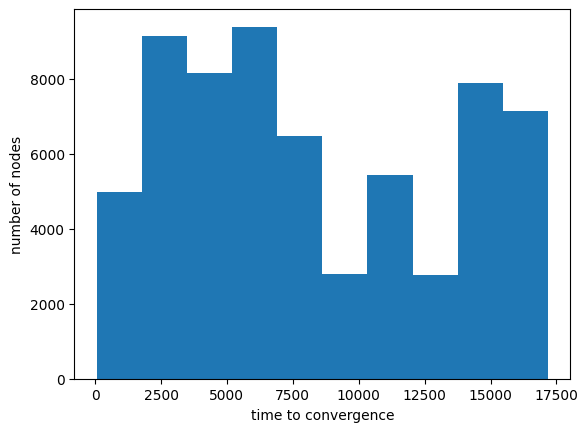

In [13]:
import matplotlib.pyplot as plt 
plt.hist(arr_times_test)
plt.xlabel('time to convergence')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

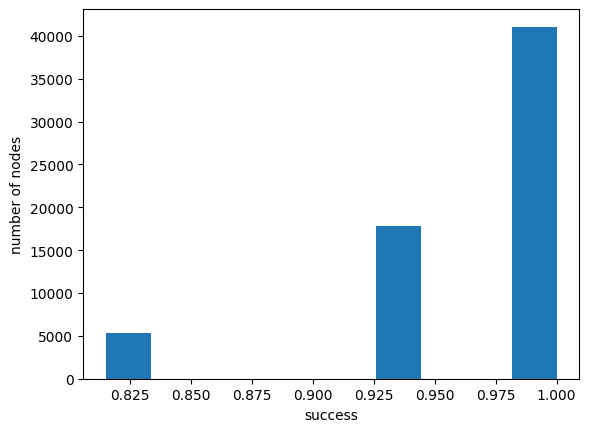

In [15]:
plt.hist(arr_success_test)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [99]:

# quorum_sims_60_40_split

fil2 = open('./data/quorum_sims_60_40_split/graphs/alltraintime.pickle', 'rb')
metatime = pickle.load(fil2)
fil2.close()
fil2 = open('./data/quorum_sims_60_40_split/graphs/alltrainsucc.pickle', 'rb')
metasucc = pickle.load(fil2)
fil2.close()

! ls -a './data/quorum_sims_60_40_split/graphs/' 

.                      alltesttime.pickle     test_means
..                     alltrainsucc.pickle    train
.DS_Store              alltraintime.pickle    train_means
alltestsucc.pickle     test                   train_near_convergence


In [93]:
import pdb
def get_succtimeclass(s, t, fl):

    if s <= SUCC_LIMIT and t > TIME_LIMIT:
        return 0 # slow fail
    elif s > SUCC_LIMIT and t > TIME_LIMIT:
        return 1 # slow success
    elif s <= SUCC_LIMIT and t <= TIME_LIMIT:
        return 2 # fast fail
    elif s > SUCC_LIMIT and t <= TIME_LIMIT:
        return 3 # fast success
    else:
        print(s, t, fl)
        pdb.set_trace()

def get_timeclass( t):
    if t > TIME_LIMIT:
        return 0
    else:
        return 1
    
def get_succclass( s):
    if s <= SUCC_LIMIT:
        return 0
    else:
        return 1

TIME_LIMIT = 2500
SUCC_LIMIT = 0.95

numentries = []
class_mean_time = []
classes_indi_time = []
class_mean_succ = []
classes_indi_succ = []
# traintimes = []
# trainsuccess = []
for m in metatime:
    # print(metatime[m])
    # print(metasucc[m])
    # pdb.set_trace()
    class_mean_time.append(get_timeclass(np.mean(metatime[m])))
    class_mean_succ.append(get_succclass(np.mean(metasucc[m])))
    time_arr = []
    succ_arr = []
    for times, succ in zip(metatime[m], metasucc[m]):
        time_arr.append(get_timeclass(times))
        succ_arr.append(get_succclass(succ))
    classes_indi_time.append(time_arr)
    classes_indi_succ.append(succ_arr)
    numentries.append(len(metatime[m]))

percent_time_classes = []
percent_succ_classes = []
# for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):
#     # pdb.set_trace()
#     percent_time_classes.append(np.mean([ctmean  if c==ctmean else 0 for c in ct]))
#     percent_succ_classes.append(np.mean([csmean if c==csmean else 0 for c in cs]))

# t1 = []
# t2 = []
# t3 = []
# t4 = []
# for i in range(0,4):
#     for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):




for ctmean, csmean, ct, cs in zip(class_mean_time, class_mean_succ, classes_indi_time, classes_indi_succ):
    # pdb.set_trace()
    if ctmean == 1 and csmean == 1:
        percent_time_classes.append(np.mean([1  if c==ctmean else 0 for c in ct]))
        percent_succ_classes.append(np.mean([1 if c==csmean else 0 for c in cs]))

# percent_time_classes = np.mean([c/np.sum([]) for c in class_mean_time])
# percent_succ_classes = 

    # break
        
# for m in metatime:
#     print(metatime[m])
#     for times in metatime[m]:
#         traintimes.append(times)

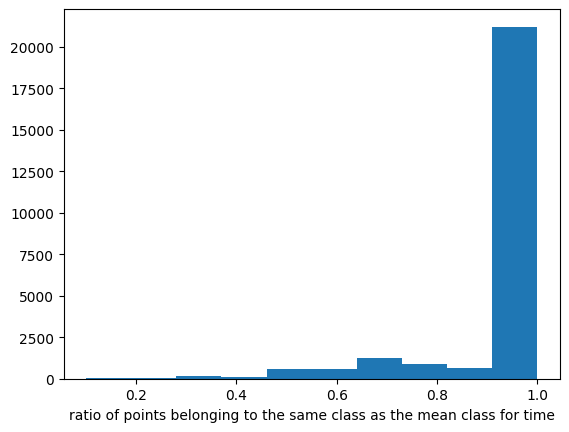

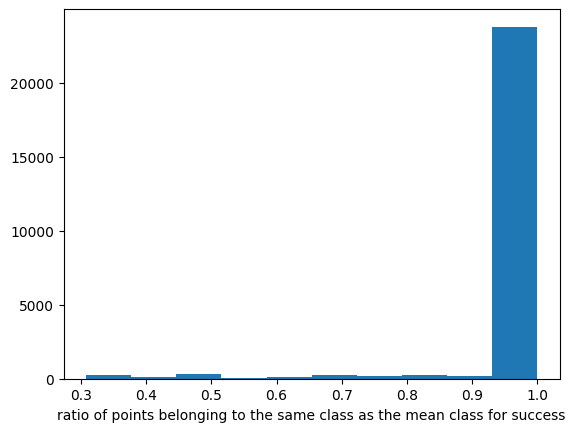

In [94]:
plt.hist(percent_time_classes)#, '.')
plt.xlabel('ratio of points belonging to the same class as the mean class for time')
# plt.xlabel('node number')
plt.show()

plt.hist(percent_succ_classes)#, '.')
plt.xlabel('ratio of points belonging to the same class as the mean class for success')
# plt.xlabel('node number')
plt.show()


Text(0, 0.5, 'number of nodes')

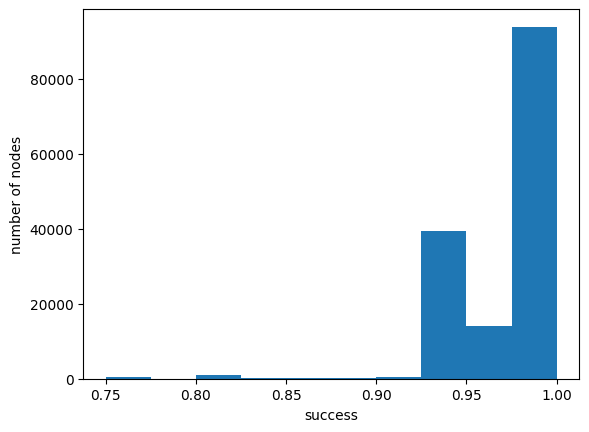

In [57]:
plt.hist(trainsuccess)
plt.xlabel('success')
plt.ylabel('number of nodes')

Text(0, 0.5, 'number of nodes')

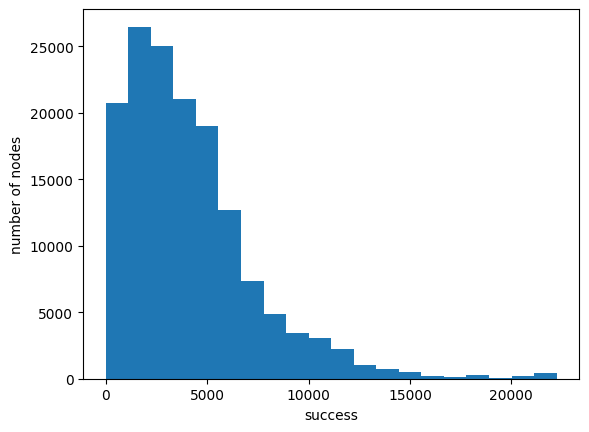

In [54]:
plt.hist(traintimes, bins=20)
plt.xlabel('success')
plt.ylabel('number of nodes')

In [ ]:
# plt.plot(h[1][:-1],h[0],'.')
# plt.xlabel('success')
# plt.ylabel('number of nodes')